In [2]:
from pathlib import Path
import platform
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    LeaveOneOut,
    RepeatedKFold,
    ShuffleSplit,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.utils import resample

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    brier_score_loss,
)

from optbinning import BinningProcess, OptimalBinning
import statsmodels.api as sm


In [3]:
df = pd.read_csv("data/ames_openml_42165.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
import pandas as pd
import sweetviz as sv


# Gera o relatório completo
relatorio = sv.analyze(df)

# Cria o arquivo HTML e já abre automaticamente no seu navegador
relatorio.show_html("resumo_sweetviz.html")


c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:05 -> (00:00 left)


Report resumo_sweetviz.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [6]:
missing = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
cols_drop = (df.isna().mean() > 0.1)
missing[missing > 10]

PoolQC         99.52
MiscFeature    96.30
Alley          93.77
Fence          80.75
MasVnrType     59.73
FireplaceQu    47.26
LotFrontage    17.74
dtype: float64

In [7]:
df.drop(columns=cols_drop, errors="ignore", inplace=True)
df.drop(columns='Id', errors="ignore", inplace=True)

In [8]:
y = pd.to_numeric(df['SalePrice'], errors='raise')
X = df.drop(columns=['SalePrice']).copy()

# Separando em train e test, mas mantendo uma estratificação igual dos quartis 10%.
# Isso é feito com preço, mas poderia ser avaliado com ano da casa e outras variáveis semelhantes

price_bins = pd.qcut(y, q=10, duplicates="drop")
train_idx, test_idx = train_test_split(
    np.arange(len(X)),
    test_size=0.2,
    stratify=price_bins
)
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print(price_bins.iloc[train_idx].value_counts(normalize=True).sort_index())
print(price_bins.iloc[test_idx].value_counts(normalize=True).sort_index())


SalePrice
(34899.999, 106475.0]    0.100171
(106475.0, 124000.0]     0.101884
(124000.0, 135500.0]     0.098459
(135500.0, 147000.0]     0.102740
(147000.0, 163000.0]     0.098459
(163000.0, 179280.0]     0.098459
(179280.0, 198620.0]     0.100171
(198620.0, 230000.0]     0.101884
(230000.0, 278000.0]     0.098459
(278000.0, 755000.0]     0.099315
Name: proportion, dtype: float64
SalePrice
(34899.999, 106475.0]    0.099315
(106475.0, 124000.0]     0.102740
(124000.0, 135500.0]     0.099315
(135500.0, 147000.0]     0.102740
(147000.0, 163000.0]     0.095890
(163000.0, 179280.0]     0.099315
(179280.0, 198620.0]     0.099315
(198620.0, 230000.0]     0.102740
(230000.0, 278000.0]     0.099315
(278000.0, 755000.0]     0.099315
Name: proportion, dtype: float64


In [9]:
split_check = pd.DataFrame({
    "conjunto": ["treino", "teste"],
    "n": [len(y_train), len(y_test)],
    "mediana": [y_train.median(), y_test.median()],
    "media": [y_train.mean(), y_test.mean()],
    "desvio": [y_train.std(), y_test.std()],
})
split_check

,conjunto,n,mediana,media,desvio
0,treino,1168,163000.0,181014.367295,79642.817905
1,teste,292,161750.0,180548.510274,78770.727247


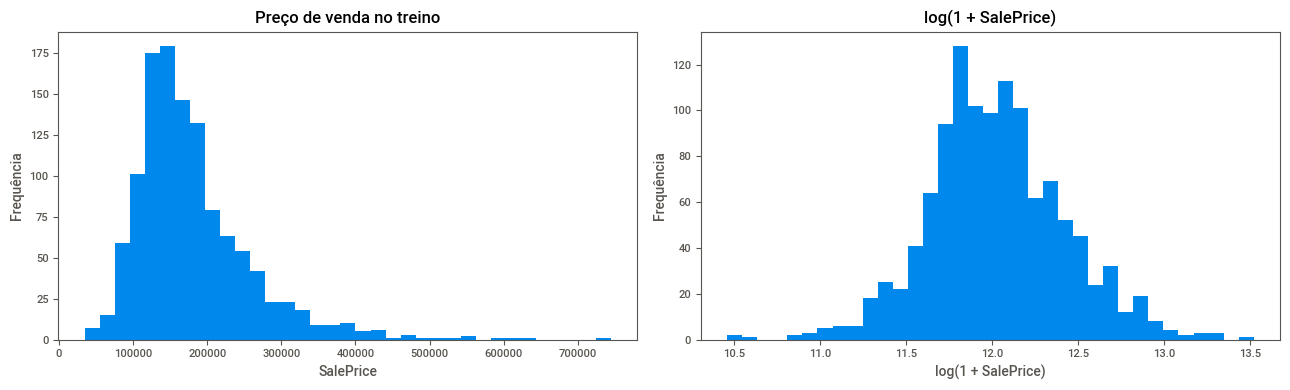

In [11]:
train_df = X_train.copy()
train_df["SalePrice"] = y_train

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_train, bins=35)
axes[0].set_title("Preço de venda no treino")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Frequência")

axes[1].hist(np.log1p(y_train), bins=35)
axes[1].set_title("log(1 + SalePrice)")
axes[1].set_xlabel("log(1 + SalePrice)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

In [14]:
numeric_cols_eda = X_train.select_dtypes(include="number").columns
corr_to_target = (
    train_df[list(numeric_cols_eda) + ["SalePrice"]]
    .corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=np.abs, ascending=False)
    .head(25)
)

corr_to_target.to_frame("correlacao_com_preco")


,correlacao_com_preco
OverallQual,0.790715
GrLivArea,0.699873
GarageCars,0.640727
GarageArea,0.625519
TotalBsmtSF,0.606773
1stFlrSF,0.602030
FullBath,0.554648
TotRmsAbvGrd,0.522875
YearRemodAdd,0.516020
YearBuilt,0.513241


In [ ]:
corr_target = (
    train_df[list(numeric_cols_eda) + ["SalePrice"]]
    .corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .abs()
)

corr_matrix = (
    train_df[numeric_cols_eda]
    .corr()
    .abs()
)


corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .rename("correlacao")
)

print(
    corr_pairs[corr_pairs.abs() > 0.7]
    .sort_values(key=np.abs, ascending=False)
)

Series([], Name: correlacao, dtype: float64)


In [18]:

cols_to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]

        if corr_matrix.loc[col1, col2] > 0.5:
            if corr_target[col1] >= corr_target[col2]:
                cols_to_drop.add(col2)
            else:
                cols_to_drop.add(col1)

X_train = X_train.drop(columns=list(cols_to_drop))
X_test = X_test.drop(columns=list(cols_to_drop))

print(f"{len(cols_to_drop)} variáveis removidas.")
print(sorted(cols_to_drop))

11 variáveis removidas.
['2ndFlrSF', 'BedroomAbvGr', 'BsmtFinSF1', 'BsmtFullBath', 'FullBath', 'GarageCars', 'GrLivArea', 'HalfBath', 'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd']


Para realizar EDA e qualquer outro tipo de análise e avaliação, manipulação nos dados, é importantes realizarmos dentro do pipeline sem alterar o dataset de teste.

Métricas e modelo baseline

In [19]:
def regression_metrics(y_true, y_pred):
    y_pred = np.asarray(y_pred).reshape(-1)
    y_true = np.asarray(y_true).reshape(-1)
    y_pred_nonnegative = np.clip(y_pred, 0, None)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "RMSLE": np.sqrt(mean_squared_log_error(y_true, y_pred_nonnegative)),
        "R2": r2_score(y_true, y_pred),
    }

baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)

baseline_train_pred = baseline.predict(X_train)
baseline_train_metrics = regression_metrics(y_train, baseline_train_pred)

pd.Series(baseline_train_metrics, name="baseline_treino")

MAE      55652.937500
RMSE     81621.475365
RMSLE        0.400423
R2          -0.051206
Name: baseline_treino, dtype: float64

In [21]:
# Target em log
y_log = np.log1p(y_train)

cv = KFold(
    n_splits=5,
    shuffle=True
)

scoring = {
    "MAE_log": "neg_mean_absolute_error",
    "RMSE_log": "neg_root_mean_squared_error",
    "R2_log": "r2",
}

results = []

In [22]:
def evaluate_model_cv(name, model, X, y, cv):
    cv_result = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    results.append({
        "modelo": name,
        "classe": model.__class__.__name__,
        "parametros": model.get_params(),
        "MAE_log_cv": -cv_result["test_MAE_log"].mean(),
        "MAE_log_std": cv_result["test_MAE_log"].std(),
        "RMSE_log_cv": -cv_result["test_RMSE_log"].mean(),
        "RMSE_log_std": cv_result["test_RMSE_log"].std(),
        "R2_log_cv": cv_result["test_R2_log"].mean(),
        "R2_log_std": cv_result["test_R2_log"].std(),
    })

    return pd.DataFrame(results)

In [23]:
baseline = DummyRegressor(strategy="median")

results_df = evaluate_model_cv(
    name="DummyRegressor_Median_LogPrice",
    model=baseline,
    X=X_train,
    y=y_log,
    cv=cv
)

results_df

,modelo,classe,parametros,MAE_log_cv,MAE_log_std,RMSE_log_cv,RMSE_log_std,R2_log_cv,R2_log_std
0,DummyRegressor_Median_LogPrice,DummyRegressor,"{'constant': None, 'quantile': None, 'strategy...",0.310015,0.011587,0.400374,0.011424,-0.005175,0.006073


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate

In [29]:
numeric_features = (
    X_train
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print(f"Variáveis numéricas: {len(numeric_features)}")
print(f"Variáveis categóricas: {len(categorical_features)}")

Variáveis numéricas: 21
Variáveis categóricas: 43


In [30]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            IterativeImputer(
                initial_strategy="median",
                max_iter=20,
                tol=1e-3,
                imputation_order="ascending",
                skip_complete=True,
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [31]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="None"
            )
        )
    ]
)

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [37]:
quality_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]

ordinal_categories = {
    "ExterQual": quality_order,
    "ExterCond": quality_order,
    "HeatingQC": quality_order,
    "KitchenQual": quality_order,
    "FireplaceQu": quality_order,
    "GarageQual": quality_order,
    "GarageCond": quality_order,
    "PoolQC": quality_order,
}

ordinal_categories.update({
    "BsmtExposure": ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": [
        "None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"
    ],
    "BsmtFinType2": [
        "None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"
    ],
    "GarageFinish": ["None", "Unf", "RFn", "Fin"],
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "PavedDrive": ["N", "P", "Y"],
})

In [38]:
categorical_features = (
    X_train
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

ordinal_features = [
    column
    for column in ordinal_categories
    if column in categorical_features
]

nominal_features = [
    column
    for column in categorical_features
    if column not in ordinal_features
]

In [39]:
for column in ordinal_features:
    observed = set(X_train[column].dropna().unique())
    expected = set(ordinal_categories[column])

    unexpected = observed - expected

    if unexpected:
        print(
            f"{column}: categorias não mapeadas: {unexpected}"
        )

In [41]:
X_train = X_train.copy()

if "MSSubClass" in X_train.columns:
    X_train["MSSubClass"] = X_train["MSSubClass"].astype(str)

In [42]:
numeric_features = (
    X_train
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

ordinal_features = [
    column
    for column in ordinal_categories
    if column in categorical_features
]

nominal_features = [
    column
    for column in categorical_features
    if column not in ordinal_features
]

print(f"Numéricas: {len(numeric_features)}")
print(f"Ordinais: {len(ordinal_features)}")
print(f"Nominais: {len(nominal_features)}")

Numéricas: 20
Ordinais: 15
Nominais: 29


In [43]:
quality_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]

ordinal_categories = {
    "ExterQual": quality_order,
    "ExterCond": quality_order,
    "HeatingQC": quality_order,
    "KitchenQual": quality_order,
    "FireplaceQu": quality_order,
    "GarageQual": quality_order,
    "GarageCond": quality_order,
    "PoolQC": quality_order,

    "BsmtQual": quality_order,
    "BsmtCond": quality_order,

    "BsmtExposure": [
        "None", "No", "Mn", "Av", "Gd"
    ],

    "BsmtFinType1": [
        "None", "Unf", "LwQ",
        "Rec", "BLQ", "ALQ", "GLQ"
    ],

    "BsmtFinType2": [
        "None", "Unf", "LwQ",
        "Rec", "BLQ", "ALQ", "GLQ"
    ],

    "GarageFinish": [
        "None", "Unf", "RFn", "Fin"
    ],

    "LotShape": [
        "IR3", "IR2", "IR1", "Reg"
    ],

    "LandSlope": [
        "Sev", "Mod", "Gtl"
    ],

    "PavedDrive": [
        "N", "P", "Y"
    ],

    "Utilities": [
        "ELO", "NoSeWa", "NoSewr", "AllPub"
    ],

    "CentralAir": [
        "N", "Y"
    ],

    "Street": [
        "Grvl", "Pave"
    ],

    "Alley": [
        "None", "Grvl", "Pave"
    ],

    "Functional": [
        "Sal", "Sev", "Maj2", "Maj1",
        "Mod", "Min2", "Min1", "Typ"
    ],

    "Fence": [
        "None", "MnWw", "GdWo", "MnPrv", "GdPrv"
    ],
}

In [44]:
categorical_features = (
    X_train
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

ordinal_features = [
    column
    for column in ordinal_categories
    if column in categorical_features
]

nominal_features = [
    column
    for column in categorical_features
    if column not in ordinal_features
]

In [45]:
for column in ordinal_features:
    observed = set(
        X_train[column]
        .fillna("None")
        .astype(str)
        .unique()
    )

    expected = set(ordinal_categories[column])

    unexpected = observed - expected

    if unexpected:
        print(
            f"{column}: categorias não mapeadas: {unexpected}"
        )

In [46]:
def build_subset_preprocessor(selected_features):
    selected_features = list(selected_features)

    selected_numeric = [
        column
        for column in selected_features
        if column in numeric_features
    ]

    selected_ordinal = [
        column
        for column in selected_features
        if column in ordinal_features
    ]

    selected_nominal = [
        column
        for column in selected_features
        if column in nominal_features
    ]

    transformers = []

    if selected_numeric:
        numeric_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    IterativeImputer(
                        initial_strategy="median",
                        max_iter=20,
                        tol=1e-3,
                        imputation_order="ascending",
                        skip_complete=True,
                        add_indicator=True,
                        random_state=42,
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ]
        )

        transformers.append(
            (
                "numeric",
                numeric_pipeline,
                selected_numeric,
            )
        )

    if selected_ordinal:
        categories = [
            ordinal_categories[column]
            for column in selected_ordinal
        ]

        ordinal_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="constant",
                        fill_value="None",
                    ),
                ),
                (
                    "encoder",
                    OrdinalEncoder(
                        categories=categories,
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                        dtype=np.float64,
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ]
        )

        transformers.append(
            (
                "ordinal",
                ordinal_pipeline,
                selected_ordinal,
            )
        )

    if selected_nominal:
        nominal_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="constant",
                        fill_value="None",
                    ),
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        drop=None,
                        sparse_output=True,
                    ),
                ),
            ]
        )

        transformers.append(
            (
                "nominal",
                nominal_pipeline,
                selected_nominal,
            )
        )

    if not transformers:
        raise ValueError(
            "Nenhuma variável válida foi selecionada."
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

In [47]:
def evaluate_feature_subset(
    X,
    y,
    selected_features,
    cv,
    estimator=None,
):
    if estimator is None:
        estimator = LinearRegression()

    preprocessor = build_subset_preprocessor(
        selected_features
    )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "model",
                estimator,
            ),
        ]
    )

    cv_results = cross_validate(
        estimator=pipeline,
        X=X[selected_features],
        y=y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
    )

    fold_rmse = -cv_results["test_score"]

    mean_rmse = fold_rmse.mean()
    std_rmse = fold_rmse.std(ddof=1)
    se_rmse = std_rmse / np.sqrt(len(fold_rmse))

    return {
        "mean_rmse": mean_rmse,
        "std_rmse": std_rmse,
        "se_rmse": se_rmse,
        "fold_rmse": fold_rmse,
    }

In [48]:
def forward_selection_cv(
    X,
    y,
    candidate_features=None,
    max_features=None,
    cv=None,
    estimator=None,
    min_improvement=0.0,
    verbose=True,
):
    if candidate_features is None:
        candidate_features = X.columns.tolist()

    candidate_features = list(candidate_features)

    missing_columns = [
        column
        for column in candidate_features
        if column not in X.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Colunas ausentes em X: {missing_columns}"
        )

    if max_features is None:
        max_features = len(candidate_features)

    max_features = min(
        max_features,
        len(candidate_features),
    )

    if cv is None:
        cv = KFold(
            n_splits=5,
            shuffle=True,
            random_state=42,
        )

    if estimator is None:
        estimator = LinearRegression()

    selected = []
    remaining = candidate_features.copy()

    path_rows = []
    previous_rmse = np.inf

    for step in range(1, max_features + 1):
        candidate_results = []

        if verbose:
            print(
                f"\nEtapa {step}: "
                f"{len(remaining)} candidatas"
            )

        for candidate in remaining:
            subset = selected + [candidate]

            result = evaluate_feature_subset(
                X=X,
                y=y,
                selected_features=subset,
                cv=cv,
                estimator=estimator,
            )

            candidate_results.append(
                {
                    "candidate": candidate,
                    "mean_rmse": result["mean_rmse"],
                    "std_rmse": result["std_rmse"],
                    "se_rmse": result["se_rmse"],
                    "fold_rmse": result["fold_rmse"],
                }
            )

        candidate_results.sort(
            key=lambda result: result["mean_rmse"]
        )

        best_candidate = candidate_results[0]
        best_feature = best_candidate["candidate"]
        best_rmse = best_candidate["mean_rmse"]

        improvement = previous_rmse - best_rmse

        if (
            selected
            and improvement < min_improvement
        ):
            if verbose:
                print(
                    "Seleção interrompida: "
                    f"melhoria de {improvement:.6f} "
                    f"menor que {min_improvement:.6f}."
                )
            break

        selected.append(best_feature)
        remaining.remove(best_feature)

        path_rows.append(
            {
                "n_features": len(selected),
                "added_feature": best_feature,
                "mean_rmse": best_candidate["mean_rmse"],
                "std_rmse": best_candidate["std_rmse"],
                "se_rmse": best_candidate["se_rmse"],
                "selected_features": selected.copy(),
                "fold_rmse": best_candidate["fold_rmse"],
            }
        )

        previous_rmse = best_rmse

        if verbose:
            print(
                f"Adicionada: {best_feature}"
            )
            print(
                f"RMSE médio: "
                f"{best_candidate['mean_rmse']:.6f}"
            )
            print(
                f"Erro-padrão: "
                f"{best_candidate['se_rmse']:.6f}"
            )

    path = pd.DataFrame(path_rows)

    return path

In [51]:
cv_forward = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

forward_path = forward_selection_cv(
    X=X_train,
    y=y_train,
    candidate_features=X_train.columns.tolist(),
    max_features=30,
    cv=cv_forward,
    estimator=LinearRegression(),
    min_improvement=0.0,
    verbose=True,
)


Etapa 1: 64 candidatas
Adicionada: OverallQual
RMSE médio: 48677.839014
Erro-padrão: 2738.709787

Etapa 2: 63 candidatas
Adicionada: Neighborhood
RMSE médio: 43946.878495
Erro-padrão: 2337.519328

Etapa 3: 62 candidatas
Adicionada: MSSubClass
RMSE médio: 41780.062271
Erro-padrão: 1861.434643

Etapa 4: 61 candidatas
Adicionada: BsmtExposure
RMSE médio: 40396.325480
Erro-padrão: 1965.028997

Etapa 5: 60 candidatas
Adicionada: KitchenQual
RMSE médio: 39129.270540
Erro-padrão: 1987.689287

Etapa 6: 59 candidatas
Adicionada: Fireplaces
RMSE médio: 38263.288329
Erro-padrão: 1943.587819

Etapa 7: 58 candidatas
Adicionada: MasVnrArea
RMSE médio: 37925.509068
Erro-padrão: 1919.175065

Etapa 8: 57 candidatas
Adicionada: Exterior1st
RMSE médio: 37563.940172
Erro-padrão: 1985.613385

Etapa 9: 56 candidatas
Adicionada: BsmtQual
RMSE médio: 37296.144275
Erro-padrão: 2035.677459

Etapa 10: 55 candidatas
Adicionada: HouseStyle
RMSE médio: 37046.035385
Erro-padrão: 1992.007978

Etapa 11: 54 candidatas

In [52]:
y_train_log = np.log1p(y_train)

forward_path = forward_selection_cv(
    X=X_train,
    y=y_train_log,
    candidate_features=X_train.columns.tolist(),
    max_features=30,
    cv=cv_forward,
    estimator=LinearRegression(),
    min_improvement=0.0,
    verbose=True,
)


Etapa 1: 64 candidatas
Adicionada: OverallQual
RMSE médio: 0.232088
Erro-padrão: 0.005103

Etapa 2: 63 candidatas
Adicionada: Neighborhood
RMSE médio: 0.205505
Erro-padrão: 0.004009

Etapa 3: 62 candidatas
Adicionada: MSSubClass
RMSE médio: 0.194780
Erro-padrão: 0.003506

Etapa 4: 61 candidatas
Adicionada: KitchenQual
RMSE médio: 0.188057
Erro-padrão: 0.003583

Etapa 5: 60 candidatas
Adicionada: Fireplaces
RMSE médio: 0.181706
Erro-padrão: 0.004150

Etapa 6: 59 candidatas
Adicionada: BsmtQual
RMSE médio: 0.176610
Erro-padrão: 0.004132

Etapa 7: 58 candidatas
Adicionada: OverallCond
RMSE médio: 0.173883
Erro-padrão: 0.003519

Etapa 8: 57 candidatas
Adicionada: GarageFinish
RMSE médio: 0.171087
Erro-padrão: 0.004630

Etapa 9: 56 candidatas
Adicionada: WoodDeckSF
RMSE médio: 0.169493
Erro-padrão: 0.004818

Etapa 10: 55 candidatas
Adicionada: BsmtFinType1
RMSE médio: 0.167970
Erro-padrão: 0.005027

Etapa 11: 54 candidatas
Adicionada: ScreenPorch
RMSE médio: 0.166913
Erro-padrão: 0.005332


In [53]:
forward_summary = forward_path[
    [
        "n_features",
        "added_feature",
        "mean_rmse",
        "std_rmse",
        "se_rmse",
    ]
].copy()

forward_summary

,n_features,added_feature,mean_rmse,std_rmse,se_rmse
0,1,OverallQual,0.232088,0.011412,0.005103
1,2,Neighborhood,0.205505,0.008964,0.004009
2,3,MSSubClass,0.194780,0.007840,0.003506
3,4,KitchenQual,0.188057,0.008011,0.003583
4,5,Fireplaces,0.181706,0.009280,0.004150
5,6,BsmtQual,0.176610,0.009240,0.004132
6,7,OverallCond,0.173883,0.007868,0.003519
7,8,GarageFinish,0.171087,0.010354,0.004630
8,9,WoodDeckSF,0.169493,0.010774,0.004818
9,10,BsmtFinType1,0.167970,0.011240,0.005027


In [ ]:
print(
    forward_path[
        [
            "n_features",
            "added_feature",
            "mean_rmse",
            "se_rmse",
        ]
    ].to_string(index=False)
)

In [54]:
best_index = forward_path["mean_rmse"].idxmin()

best_row = forward_path.loc[best_index]

best_n_features = int(
    best_row["n_features"]
)

best_rmse = best_row["mean_rmse"]
best_se = best_row["se_rmse"]

one_se_limit = best_rmse + best_se

print(f"Menor RMSE: {best_rmse:.6f}")
print(
    f"Número de variáveis no mínimo: "
    f"{best_n_features}"
)
print(
    f"Limite da regra de 1-SE: "
    f"{one_se_limit:.6f}"
)

Menor RMSE: 0.158144
Número de variáveis no mínimo: 30
Limite da regra de 1-SE: 0.163312


In [55]:
eligible_models = forward_path[
    forward_path["mean_rmse"] <= one_se_limit
].sort_values("n_features")

one_se_row = eligible_models.iloc[0]

one_se_n_features = int(
    one_se_row["n_features"]
)

one_se_rmse = one_se_row["mean_rmse"]

selected_features_1se = one_se_row[
    "selected_features"
]

print(
    f"Modelo escolhido pela regra de 1-SE: "
    f"{one_se_n_features} variáveis"
)

print(
    f"RMSE médio do modelo de 1-SE: "
    f"{one_se_rmse:.6f}"
)

print("\nVariáveis selecionadas:")

for feature in selected_features_1se:
    print(f"- {feature}")

Modelo escolhido pela regra de 1-SE: 15 variáveis
RMSE médio do modelo de 1-SE: 0.163111

Variáveis selecionadas:
- OverallQual
- Neighborhood
- MSSubClass
- KitchenQual
- Fireplaces
- BsmtQual
- OverallCond
- GarageFinish
- WoodDeckSF
- BsmtFinType1
- ScreenPorch
- CentralAir
- Heating
- Foundation
- LotConfig


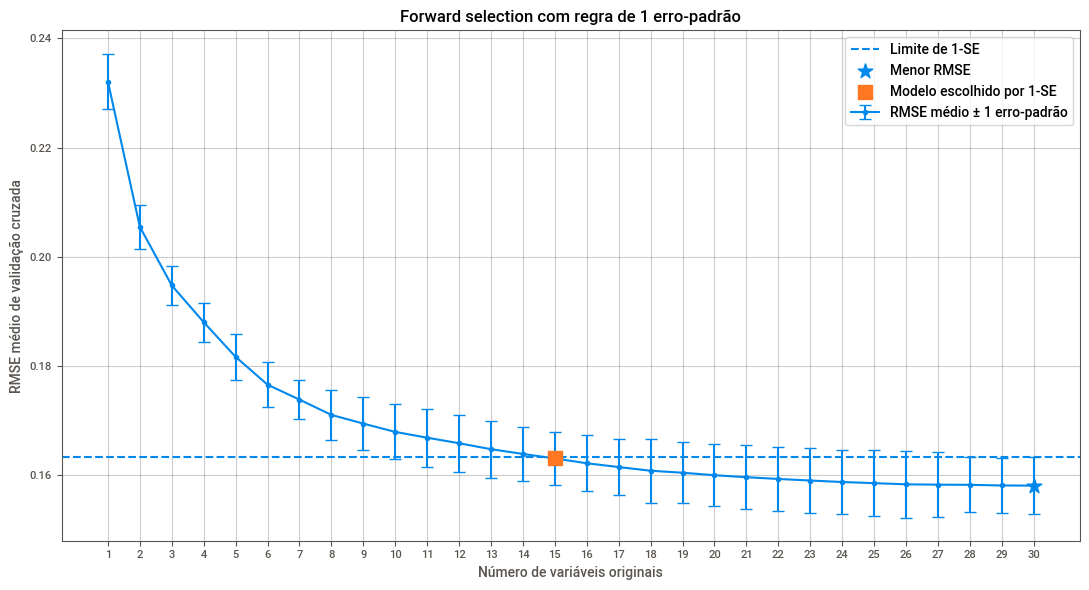

In [56]:
plt.figure(figsize=(11, 6))

plt.errorbar(
    forward_path["n_features"],
    forward_path["mean_rmse"],
    yerr=forward_path["se_rmse"],
    marker="o",
    capsize=4,
    label="RMSE médio ± 1 erro-padrão",
)

plt.axhline(
    y=one_se_limit,
    linestyle="--",
    label="Limite de 1-SE",
)

plt.scatter(
    best_n_features,
    best_rmse,
    s=120,
    marker="*",
    zorder=3,
    label="Menor RMSE",
)

plt.scatter(
    one_se_n_features,
    one_se_rmse,
    s=100,
    marker="s",
    zorder=3,
    label="Modelo escolhido por 1-SE",
)

plt.xlabel("Número de variáveis originais")
plt.ylabel("RMSE médio de validação cruzada")
plt.title(
    "Forward selection com regra de 1 erro-padrão"
)
plt.xticks(
    forward_path["n_features"]
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
sum(
    len(X_train.columns) - step
    for step in range(30)
)

1485

In [58]:
from sklearn.base import clone
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, KFold

In [59]:
cv_regularization = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

selected_features_1se = list(selected_features_1se)

preprocessor_regularization = build_subset_preprocessor(
    selected_features_1se
)

In [60]:
ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_regularization),
        ),
        (
            "model",
            Ridge(
                max_iter=20_000,
            ),
        ),
    ]
)

ridge_param_grid = {
    "model__alpha": np.logspace(
        -4,
        4,
        81,
    )
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_regularization,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
    error_score="raise",
)

ridge_search.fit(
    X_train[selected_features_1se],
    y_train_log,
)

print(
    "Melhor alpha Ridge:",
    ridge_search.best_params_["model__alpha"],
)

print(
    "Melhor RMSE Ridge:",
    -ridge_search.best_score_,
)

Melhor alpha Ridge: 1.9952623149688788
Melhor RMSE Ridge: 0.16251440106221715


In [61]:
lasso_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_regularization),
        ),
        (
            "model",
            Lasso(
                max_iter=50_000,
                tol=1e-4,
                selection="cyclic",
            ),
        ),
    ]
)

lasso_param_grid = {
    "model__alpha": np.logspace(
        -5,
        1,
        81,
    )
}

lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_regularization,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
    error_score="raise",
)

lasso_search.fit(
    X_train[selected_features_1se],
    y_train_log,
)

print(
    "Melhor alpha Lasso:",
    lasso_search.best_params_["model__alpha"],
)

print(
    "Melhor RMSE Lasso:",
    -lasso_search.best_score_,
)

Melhor alpha Lasso: 0.00018836490894898002
Melhor RMSE Lasso: 0.1627189016733323


In [62]:
elastic_net_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_regularization),
        ),
        (
            "model",
            ElasticNet(
                max_iter=50_000,
                tol=1e-4,
                selection="cyclic",
            ),
        ),
    ]
)

elastic_net_param_grid = {
    "model__alpha": np.logspace(
        -5,
        1,
        61,
    ),
    "model__l1_ratio": [
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
    ],
}

elastic_net_search = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid=elastic_net_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_regularization,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
    error_score="raise",
)

elastic_net_search.fit(
    X_train[selected_features_1se],
    y_train_log,
)

print(
    "Melhor alpha Elastic Net:",
    elastic_net_search.best_params_[
        "model__alpha"
    ],
)

print(
    "Melhor l1_ratio Elastic Net:",
    elastic_net_search.best_params_[
        "model__l1_ratio"
    ],
)

print(
    "Melhor RMSE Elastic Net:",
    -elastic_net_search.best_score_,
)

Melhor alpha Elastic Net: 0.0012589254117941675
Melhor l1_ratio Elastic Net: 0.05
Melhor RMSE Elastic Net: 0.1625771474191585


In [63]:
regularized_results = pd.DataFrame(
    {
        "modelo": [
            "Ridge",
            "Lasso",
            "Elastic Net",
        ],
        "rmse_cv": [
            -ridge_search.best_score_,
            -lasso_search.best_score_,
            -elastic_net_search.best_score_,
        ],
        "alpha": [
            ridge_search.best_params_[
                "model__alpha"
            ],
            lasso_search.best_params_[
                "model__alpha"
            ],
            elastic_net_search.best_params_[
                "model__alpha"
            ],
        ],
        "l1_ratio": [
            np.nan,
            1.0,
            elastic_net_search.best_params_[
                "model__l1_ratio"
            ],
        ],
    }
).sort_values(
    "rmse_cv",
    ascending=True,
    ignore_index=True,
)

regularized_results

,modelo,rmse_cv,alpha,l1_ratio
0,Ridge,0.162514,1.995262,NaN
1,Elastic Net,0.162577,0.001259,0.05
2,Lasso,0.162719,0.000188,1.00


In [64]:
searches = {
    "Ridge": ridge_search,
    "Lasso": lasso_search,
    "Elastic Net": elastic_net_search,
}

best_model_name = regularized_results.loc[
    0,
    "modelo",
]

best_search = searches[best_model_name]
best_pipeline = best_search.best_estimator_

print(
    f"Melhor modelo: {best_model_name}"
)

print(
    f"RMSE médio em log: "
    f"{-best_search.best_score_:.6f}"
)

print(
    "Melhores hiperparâmetros:"
)

print(
    best_search.best_params_
)

Melhor modelo: Ridge
RMSE médio em log: 0.162514
Melhores hiperparâmetros:
{'model__alpha': np.float64(1.9952623149688788)}


In [ ]:
best_cv_results = cross_validate(
    estimator=clone(best_pipeline),
    X=X_train[selected_features_1se],
    y=y_train_log,
    cv=cv_regularization,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
    error_score="raise",
)

best_fold_rmse = (
    -best_cv_results["test_score"]
)

best_train_rmse = (
    -best_cv_results["train_score"]
)

best_cv_summary = pd.DataFrame(
    {
        "fold": np.arange(
            1,
            len(best_fold_rmse) + 1,
        ),
        "rmse_treino": best_train_rmse,
        "rmse_validacao": best_fold_rmse,
    }
)

best_cv_summary

,fold,rmse_treino,rmse_validacao
0,1,0.148917,0.175776
1,2,0.155398,0.147525
2,3,0.151150,0.170255
3,4,0.152401,0.161140
4,5,0.153755,0.157875


In [66]:
best_rmse_mean = best_fold_rmse.mean()

best_rmse_std = best_fold_rmse.std(
    ddof=1
)

best_rmse_se = (
    best_rmse_std
    / np.sqrt(len(best_fold_rmse))
)

print(
    f"RMSE médio: {best_rmse_mean:.6f}"
)

print(
    f"Desvio-padrão: {best_rmse_std:.6f}"
)

print(
    f"Erro-padrão: {best_rmse_se:.6f}"
)

RMSE médio: 0.162514
Desvio-padrão: 0.010999
Erro-padrão: 0.004919


In [70]:
X_test = X_test.copy()

if "MSSubClass" in X_test.columns:
    X_test["MSSubClass"] = (
        X_test["MSSubClass"]
        .astype(str)
    )

In [71]:
y_pred_log = best_pipeline.predict(
    X_test[selected_features_1se]
)

In [72]:
y_pred = np.expm1(
    y_pred_log
)

In [73]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

y_test_log = np.log1p(
    y_test
)

test_rmse_log = mean_squared_error(
    y_test_log,
    y_pred_log,
) ** 0.5

test_rmse_original = mean_squared_error(
    y_test,
    y_pred,
) ** 0.5

test_mae_original = mean_absolute_error(
    y_test,
    y_pred,
)

test_r2_original = r2_score(
    y_test,
    y_pred,
)

print(
    f"RMSE teste em log: "
    f"{test_rmse_log:.6f}"
)

print(
    f"RMSE teste na escala original: "
    f"{test_rmse_original:.2f}"
)

print(
    f"MAE teste na escala original: "
    f"{test_mae_original:.2f}"
)

print(
    f"R² teste na escala original: "
    f"{test_r2_original:.4f}"
)

RMSE teste em log: 0.153519
RMSE teste na escala original: 31486.45
MAE teste na escala original: 20850.71
R² teste na escala original: 0.8397
